In [3]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split

import torch
from torchvision import datasets, transforms

from collections import Counter
import shutil

In [1]:
import sys

print(sys.executable)

c:\Users\devan\AI_textile_waste_management_system\ai_models\venv\Scripts\python.exe


In [13]:
from pathlib import Path

DATASET_PATH = Path("../datasets/raw/biodegradable_fabrics")

print("Dataset Path:", DATASET_PATH)
print("Dataset Exists:", DATASET_PATH.exists())

Dataset Path: ..\datasets\raw\biodegradable_fabrics
Dataset Exists: True


In [14]:
dataset = datasets.ImageFolder(DATASET_PATH)

print("=" * 50)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 50)

print(f"Total Images : {len(dataset)}")
print(f"Total Classes: {len(dataset.classes)}")

print("\nFabric Classes:")

for idx, class_name in enumerate(dataset.classes):
    print(f"{idx + 1}. {class_name}")

DATASET LOADED SUCCESSFULLY
Total Images : 900
Total Classes: 6

Fabric Classes:
1. Abaca
2. Cotton
3. Hessian
4. Linen
5. Silk
6. Wool


In [15]:
summary = []

for class_name in dataset.classes:

    folder = DATASET_PATH / class_name

    image_count = len(list(folder.glob("*.jpg")))

    summary.append([class_name, image_count])

summary_df = pd.DataFrame(
    summary,
    columns=["Fabric Type", "Number of Images"]
)

summary_df

,Fabric Type,Number of Images
0,Abaca,150
1,Cotton,150
2,Hessian,150
3,Linen,150
4,Silk,150
5,Wool,150


In [7]:
from pathlib import Path

raw_path = Path("../datasets/raw")

print("Raw folder exists:", raw_path.exists())

print("\nFolders inside raw:")

for item in raw_path.iterdir():
    print(item.name)

Raw folder exists: True

Folders inside raw:
Biodegradable Fabrics
fashion-mnist_test-selected-columns.csv
TFD


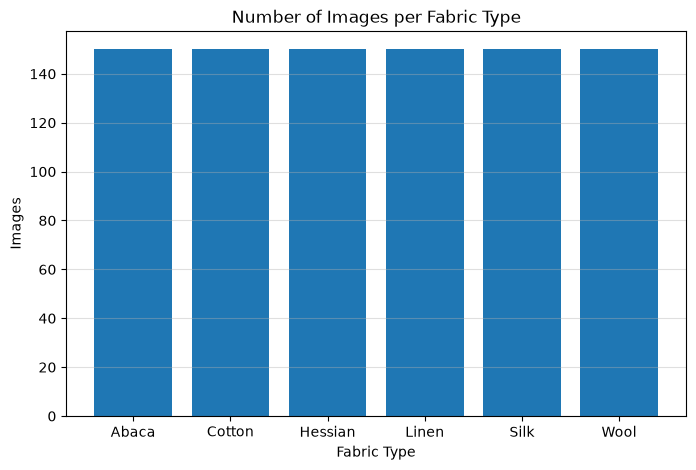

In [16]:
plt.figure(figsize=(8,5))

plt.bar(
    summary_df["Fabric Type"],
    summary_df["Number of Images"]
)

plt.title("Number of Images per Fabric Type")

plt.xlabel("Fabric Type")
plt.ylabel("Images")

plt.grid(axis="y", alpha=0.4)

plt.show()

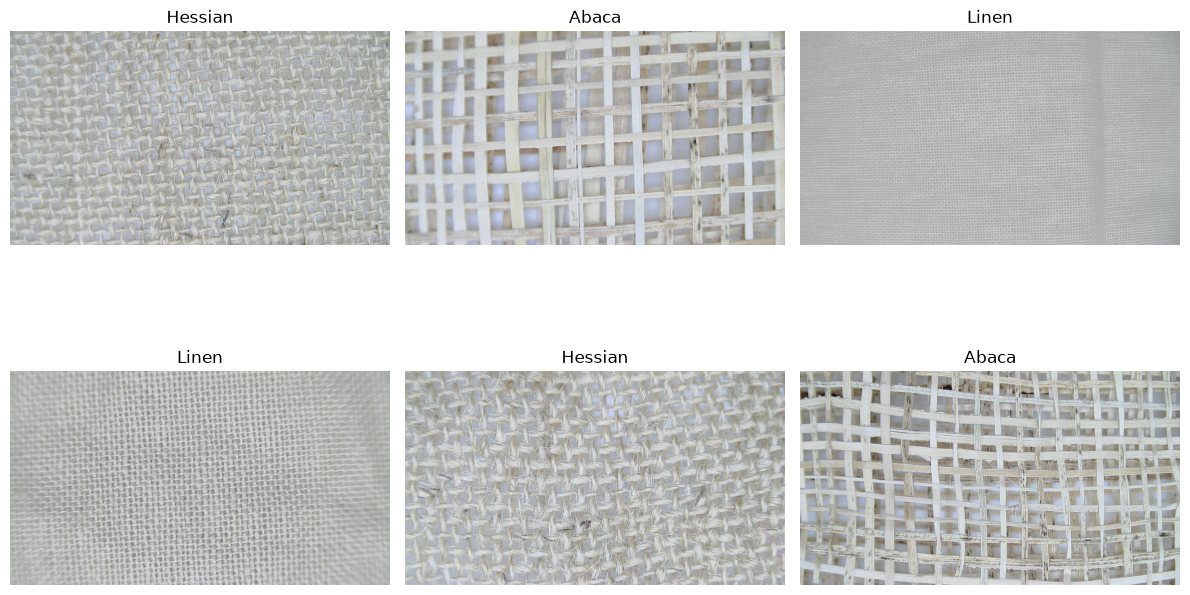

In [17]:
fig, axes = plt.subplots(2,3, figsize=(12,8))

axes = axes.flatten()

for i in range(6):

    image, label = dataset[random.randint(0, len(dataset)-1)]

    axes[i].imshow(image)

    axes[i].set_title(dataset.classes[label])

    axes[i].axis("off")

plt.tight_layout()

plt.show()

In [18]:
sizes = []

for path, _ in dataset.samples:

    img = Image.open(path)

    sizes.append(img.size)

sizes = np.array(sizes)

print("Unique Image Sizes")

print(np.unique(sizes, axis=0))

Unique Image Sizes
[[2560 1440]]


In [19]:
corrupted = []

for path, _ in dataset.samples:

    try:
        img = Image.open(path)
        img.verify()

    except Exception:
        corrupted.append(path)

print("Corrupted Images:", len(corrupted))

Corrupted Images: 0


In [20]:
from sklearn.model_selection import train_test_split

indices = list(range(len(dataset)))
labels = [label for _, label in dataset.samples]

# 70% train, 30% temporary
train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    stratify=labels,
    random_state=42
)

temp_labels = [labels[i] for i in temp_idx]

# Split remaining 30% into 15% validation and 15% test
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=temp_labels,
    random_state=42
)

print(f"Training Images   : {len(train_idx)}")
print(f"Validation Images : {len(val_idx)}")
print(f"Testing Images    : {len(test_idx)}")

Training Images   : 630
Validation Images : 135
Testing Images    : 135


In [21]:
from collections import Counter

train_labels = [labels[i] for i in train_idx]
val_labels = [labels[i] for i in val_idx]
test_labels = [labels[i] for i in test_idx]

print("Train")
print(Counter(train_labels))

print("\nValidation")
print(Counter(val_labels))

print("\nTest")
print(Counter(test_labels))

Train
Counter({4: 105, 0: 105, 5: 105, 1: 105, 2: 105, 3: 105})

Validation
Counter({0: 23, 1: 23, 5: 23, 3: 22, 4: 22, 2: 22})

Test
Counter({2: 23, 4: 23, 3: 23, 1: 22, 0: 22, 5: 22})


In [22]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

print("Transforms created successfully!")

Transforms created successfully!


In [23]:
class_names = dataset.classes

print(class_names)

['Abaca', 'Cotton', 'Hessian', 'Linen', 'Silk', 'Wool']
